In [1]:
%matplotlib inline

In [2]:
import os
import json
import warnings
warnings.filterwarnings("ignore")

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
from sklearn.decomposition import PCA
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_squared_log_error,
    r2_score,
)

In [5]:
from xgboost import XGBRegressor

In [6]:
RANDOM_STATE = 42
USE_GPU = True
N_COMPONENTS = 20

In [7]:
# ---- 0. Paths ----
DATA_DIR = r"E:\NSU\cse445\EDA attempt3\Dataset\ML dataset"
TRAIN_FILE = f"{DATA_DIR}/ML_train.csv"
TEST_FILE = f"{DATA_DIR}/ML_test.csv"

In [8]:
EMBEDDING_FILES = {
    "BERT":       r"E:\NSU\cse445\EDA attempt3\NLP models\embeddings\bert_embeddings.csv",
    "DistilBERT": r"E:\NSU\cse445\EDA attempt3\NLP models\embeddings\distilbert_embeddings.csv",
}

In [9]:
# ---- 1. Fixed hyperparameters (BERT's BayesSearchCV optimum, held constant for both) ----
FIXED_PARAMS = {
    "colsample_bytree": 0.9512165066659852,
    "learning_rate": 0.07643904937766527,
    "max_depth": 6,
    "min_child_weight": 7,
    "n_estimators": 459,
    "reg_alpha": 0.0014729254229045347,
    "reg_lambda": 0.845771345696438,
    "subsample": 0.8060762192885254,
}

In [10]:
# ---- 2. Load tabular data ----
train_df = pd.read_csv(TRAIN_FILE)
test_df = pd.read_csv(TEST_FILE)

In [11]:
TARGET_RAW = "target_usd"
TARGET_LOG = "log_target"
DROP_FROM_X = ["id", "target_usd", "log_target", "goal_usd"]

In [12]:
train_ids = set(train_df["id"])

In [13]:
# ---- 3. Evaluation helper ----
def evaluate_model(y_true_log, pred_log, actual_usd):
    pred_usd = np.expm1(pred_log)
    pred_usd = np.clip(pred_usd, a_min=0, a_max=None)

    mae_log = mean_absolute_error(y_true_log, pred_log)
    mse_log = mean_squared_error(y_true_log, pred_log)
    rmse_log = np.sqrt(mse_log)
    r2_log = r2_score(y_true_log, pred_log)

    mae_usd = mean_absolute_error(actual_usd, pred_usd)
    mse_usd = mean_squared_error(actual_usd, pred_usd)
    rmse_usd = np.sqrt(mse_usd)
    r2_usd = r2_score(actual_usd, pred_usd)

    rmsle = np.sqrt(mean_squared_log_error(actual_usd, pred_usd))

    return {
        "MAE_log": mae_log, "MSE_log": mse_log, "RMSE_log": rmse_log, "R2_log": r2_log,
        "MAE_USD": mae_usd, "MSE_USD": mse_usd, "RMSE_USD": rmse_usd, "R2_USD": r2_usd,
        "RMSLE": rmsle
    }

In [14]:
# ---- 4. Ablation loop: same fixed XGBoost params, only embedding changes ----
ablation_results = []

In [15]:
for embed_name, path in EMBEDDING_FILES.items():
    print(f"\n{'='*70}")
    print(f"EMBEDDING = {embed_name}")
    print(f"{'='*70}")

    embed_raw = pd.read_csv(path)
    feature_cols = [c for c in embed_raw.columns if c != "id"]
    train_mask = embed_raw["id"].isin(train_ids)

    pca = PCA(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
    pca.fit(embed_raw.loc[train_mask, feature_cols])
    reduced_all = pca.transform(embed_raw[feature_cols])

    reduced_cols = [f"emb_pca_{i}" for i in range(N_COMPONENTS)]
    reduced_df = pd.DataFrame(reduced_all, columns=reduced_cols)
    reduced_df.insert(0, "id", embed_raw["id"].values)

    explained = pca.explained_variance_ratio_.sum()
    print(f"Explained variance ({embed_name}): {explained:.3f}")

    merged_train = train_df.merge(reduced_df, on="id", how="left")
    merged_test = test_df.merge(reduced_df, on="id", how="left")

    assert merged_train.shape[0] == train_df.shape[0]
    assert merged_test.shape[0] == test_df.shape[0]
    assert merged_train[reduced_cols].isna().sum().sum() == 0
    assert merged_test[reduced_cols].isna().sum().sum() == 0

    X_train = merged_train.drop(columns=DROP_FROM_X, errors="ignore")
    X_test = merged_test.drop(columns=DROP_FROM_X, errors="ignore")
    y_train = merged_train[TARGET_LOG].copy()
    y_test = merged_test[TARGET_LOG].copy()
    actual_usd = merged_test[TARGET_RAW].to_numpy()

    assert list(X_train.columns) == list(X_test.columns)

    model = XGBRegressor(
        objective="reg:squarederror", eval_metric="rmse",
        tree_method="hist", device="cuda" if USE_GPU else "cpu",
        random_state=RANDOM_STATE,
        **FIXED_PARAMS,
    )
    model.fit(X_train, y_train)
    pred_log = model.predict(X_test)

    metrics = evaluate_model(y_test, pred_log, actual_usd)
    metrics["Embedding"] = embed_name
    metrics["Explained_Variance"] = explained

    ablation_results.append(metrics)

    print(f"RMSLE={metrics['RMSLE']:.4f} | R2_log={metrics['R2_log']:.4f} | "
          f"R2_USD={metrics['R2_USD']:.4f}")


EMBEDDING = BERT
Explained variance (BERT): 0.727
RMSLE=1.5065 | R2_log=0.7578 | R2_USD=0.1769

EMBEDDING = DistilBERT
Explained variance (DistilBERT): 0.768
RMSLE=1.7344 | R2_log=0.6797 | R2_USD=0.1122


In [16]:
# ---- 5. Results table ----
results_df = pd.DataFrame(ablation_results)
results_df = results_df[[
    "Embedding", "Explained_Variance",
    "MAE_log", "MSE_log", "RMSE_log", "R2_log",
    "MAE_USD", "MSE_USD", "RMSE_USD", "R2_USD", "RMSLE"
]]
print("\n" + "="*70)
print("ABLATION RESULTS: BERT vs DistilBERT (XGBoost fixed)")
print("="*70)
print(results_df)


ABLATION RESULTS: BERT vs DistilBERT (XGBoost fixed)
    Embedding  Explained_Variance   MAE_log   MSE_log  RMSE_log    R2_log  \
0        BERT            0.726705  1.115845  2.275488  1.508472  0.757791   
1  DistilBERT            0.768394  1.278010  3.008966  1.734637  0.679718   

        MAE_USD       MSE_USD       RMSE_USD    R2_USD     RMSLE  
0  14587.044370  9.713670e+09   98557.950385  0.176912  1.506474  
1  15187.138705  1.047783e+10  102361.249197  0.112161  1.734354  


In [17]:
results_df.to_csv("cross_embedding_bert_distilbert_results.csv", index=False)
print("\nSaved: cross_embedding_bert_distilbert_results.csv")


Saved: cross_embedding_bert_distilbert_results.csv


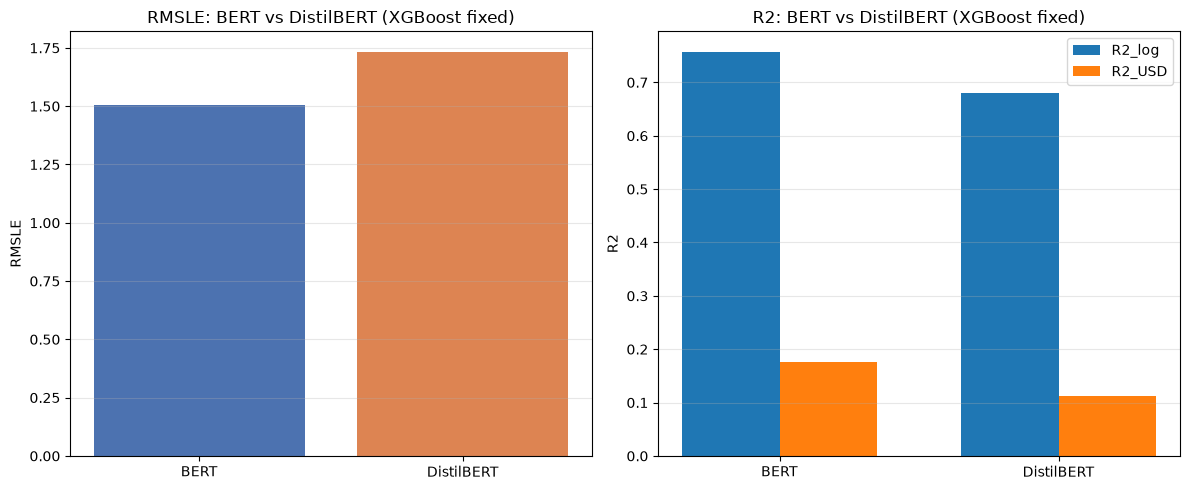

Saved: cross_embedding_bert_distilbert_plot.png


In [22]:
# ---- 6. Plot (single cell) ----
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].bar(results_df["Embedding"], results_df["RMSLE"], color=["#4C72B0", "#DD8452"])
axes[0].set_ylabel("RMSLE")
axes[0].set_title("RMSLE: BERT vs DistilBERT (XGBoost fixed)")
axes[0].grid(True, alpha=0.3, axis="y")
x = np.arange(len(results_df))
width = 0.35
axes[1].bar(x - width/2, results_df["R2_log"], width, label="R2_log")
axes[1].bar(x + width/2, results_df["R2_USD"], width, label="R2_USD")
axes[1].set_xticks(x)
axes[1].set_xticklabels(results_df["Embedding"])
axes[1].set_ylabel("R2")
axes[1].set_title("R2: BERT vs DistilBERT (XGBoost fixed)")
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("cross_embedding_bert_distilbert_plot.png", dpi=150)
plt.show()
print("Saved: cross_embedding_bert_distilbert_plot.png")

<Figure size 640x480 with 0 Axes>

Saved: cross_embedding_bert_distilbert_plot.png
